# **Directed Influence Networks in Financial Systems: Granger Causality and Transfer Entropy, Part 2**

## Summary of Part 1 and Motivation for Rolling Analysis

In [Part 1](https://github.com/BenjaminZYT/Risk-Management/blob/main/Directed_Influence_Networks_Granger_Causality_and_Transfer_Entropy_Part1.ipynb), we addressed a fundamental challenge in quantitative finance: **how to identify directional influence in a complex system of interacting assets**. In large financial ecosystems such as global foreign exchange markets, simple visual inspection or pairwise correlation analysis is insufficient to uncover the structure of influence. Relationships are often **lagged, directional, and potentially nonlinear**, making it difficult to determine which variables act as drivers and which act as responders.

To address this, we introduced two complementary methodologies for constructing directed influence networks:

- **Granger causality**, a linear, model-based approach that identifies whether past values of one time series improve the prediction of another.
- **Transfer entropy (TE)**, an information-theoretic, nonlinear measure that quantifies the incremental predictive content of one process for another.

Both methods allow us to move beyond undirected dependence (e.g., correlation) and instead construct **directed, lag-aware networks** of influence. Using these tools, we performed a full-sample analysis on a set of global currencies and derived several key outputs:
- Pairwise directed influence measures across all currency pairs,
- Rankings of currencies based on average outgoing influence (information leadership),
- Network visualizations and structural decomposition via strongly connected components and condensation.

A key empirical finding was that both Granger causality and transfer entropy produced **remarkably similar network structures**, suggesting that the dominant dependencies in the dataset are largely linear in nature.

However, this full-sample analysis provides only a **static, time-averaged view** of the system. In reality, financial markets are dynamic, and relationships between assets evolve across time due to changing macroeconomic conditions, policy regimes, and market sentiment.

---

## Part 2: Rolling Analysis

In this notebook, we extend the analysis to a **rolling framework**, allowing the influence network to evolve over time. Instead of estimating relationships over the entire sample, we compute transfer entropy and Granger causality over **moving windows**, producing a sequence of time-indexed networks.

This enables a richer set of analyses, including:

- **Rolling average influence**: tracking how the overall level of influence (TE/GC) changes over time across the system.
- **Persistent leaders**: identifying currencies that consistently rank as top information sources across different periods.
- **Top-\(k\) leaders over time**: examining how the set of dominant currencies evolves, including entry and exit dynamics among the most influential nodes.
- **Temporal stability vs. regime shifts**: detecting periods where the network structure is stable versus periods of structural change.
- **Evolution of network topology**: observing how connectivity, clustering, and hierarchy change across time.
- **Absorption ratio (AR)**: measuring the degree of systemic concentration by quantifying how much of the system’s variance is explained by a small number of dominant factors.
- **Eigenvector centrality (EC)**: identifying structurally important currencies based on their embeddedness within the network of influence.
- **Animated network visualization**: constructing time-lapse representations of the network to visually track how influence propagates and reorganizes day by day.

By moving to a rolling analysis, we shift from a static description to a **dynamic characterization of influence**, allowing us to study not only *who influences whom*, but also *when* and *under what conditions* these relationships strengthen, weaken, or reverse.

This dynamic perspective is essential for understanding real-world financial systems, where structure is not fixed but continuously evolving.

## Data and Setup

The dataset used in this analysis, [`forex_cleaned.csv`](https://github.com/BenjaminZYT/Risk-Management/blob/main/data/forex_cleaned.csv), is obtained from *Bank Negara Malaysia* (the central bank of Malaysia) and represents the middle rates of foreign exchange against MYR, quoted at noon.

The analysis focuses on the following set of currencies:

| Symbol | Currency Name           |   | Symbol | Currency Name           |   | Symbol | Currency Name           |
|--------|------------------------|---|--------|------------------------|---|--------|------------------------|
| USD    | US Dollar              |   | HKD100 | Hong Kong Dollar (100) |   | VND100 | Vietnamese Dong (100)  |
| GBP    | British Pound Sterling |   | PHP100 | Philippine Peso (100)  |   | KHR100 | Cambodian Riel (100)   |
| EUR    | Euro                   |   | THB100 | Thai Baht (100)        |   | NZD    | New Zealand Dollar     |
| JPY100 | Japanese Yen (100)     |   | TWD100 | Taiwan Dollar (100)    |   | MMK100 | Myanmar Kyat (100)     |
| CHF    | Swiss Franc            |   | KRW100 | South Korean Won (100) |   | INR100 | Indian Rupee (100)     |
| AUD    | Australian Dollar      |   | IDR100 | Indonesian Rupiah (100)|   | AED100 | UAE Dirham (100)       |
| CAD    | Canadian Dollar        |   | SAR100 | Saudi Riyal (100)      |   | PKR100 | Pakistani Rupee (100)  |
| SGD    | Singapore Dollar       |   | CNY    | Chinese Yuan           |   | NPR100 | Nepalese Rupee (100)   |
| BND    | Brunei Dollar          |   | EGP    | Egyptian Pound         |   |        |                        |

We now proceed directly to the setup stage, which includes the installation and compatibility adjustments required for the transfer entropy implementation. As in Part 1, the user may execute the setup cell directly without inspecting the underlying code, as it serves only to ensure that the required libraries function correctly in the current environment.

In [1]:
# =========================================================
# Transfer Entropy setup for PyCausality
# =========================================================

# 1. Install required packages
!pip install PyCausality --no-deps
!pip install six

# 2. Standard imports
import numpy as np
import pandas as pd
import scipy
import sys

# 3. NumPy compatibility patch
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'int'):
    np.int = int

# 4. scipy._lib.six compatibility patch
try:
    import six
except ImportError:
    !pip install six
    import six

if not hasattr(scipy, '_lib'):
    scipy._lib = type('obj', (object,), {})()

sys.modules['scipy._lib.six'] = six
print("Scipy dependency patch applied.")

# 5. Import PyCausality and the required internal modules
try:
    import PyCausality
    import PyCausality.Utils.Utils
    from PyCausality.TransferEntropy import TransferEntropy
    print("PyCausality loaded successfully.")
except ImportError:
    print("PyCausality not found. Re-installing...")
    !pip install PyCausality --no-deps
    import PyCausality
    import PyCausality.Utils.Utils
    from PyCausality.TransferEntropy import TransferEntropy

# 6. Define the KDE patch exactly as before
from sklearn.neighbors import KernelDensity

def ModernKDE(data, bandwidth='official'):
    if bandwidth == 'official':
        n = len(data)
        bandwidth = 1.06 * np.std(data) * n**(-1/5)
        if bandwidth <= 0:
            bandwidth = 0.1

    kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian')
    kde.fit(data.reshape(-1, 1))

    class KDE_Result:
        def __init__(self, kde, data):
            self.kde = kde
            self.data = data

        def evaluate(self, points):
            return np.exp(self.kde.score_samples(points.reshape(-1, 1)))

    return KDE_Result(kde, data)

# 7. Apply the patch
PyCausality.Utils.Utils._kde_ = ModernKDE
print("KDE patch applied successfully.")

# 8. Final import confirmation
try:
    from PyCausality.TransferEntropy import TransferEntropy
    print("✅ Success! The TransferEntropy module is ready.")
except ImportError as e:
    print(f"❌ Missing a dependency: {e}")
except Exception as e:
    print(f"❌ Found a code conflict: {e}")

Scipy dependency patch applied.
PyCausality loaded successfully.
KDE patch applied successfully.
✅ Success! The TransferEntropy module is ready.


We begin by loading and preparing the dataset. This includes parsing the date column, defining the set of currencies under consideration, and computing log returns, which will serve as the input for the rolling causality analysis that follows.

In [2]:
# =========================================================
# Data Preparation (Part 2)
# =========================================================

import pandas as pd
import numpy as np

# --- 1. Load data ---
df_forex = pd.read_csv("forex_cleaned.csv")

# --- 2. Identify and parse date column ---
date_col = None
for candidate in ["date", "Date", "DATE"]:
    if candidate in df_forex.columns:
        date_col = candidate
        break

if date_col is None:
    raise ValueError("No date column found in dataset.")

df_forex[date_col] = pd.to_datetime(df_forex[date_col])
df_forex = df_forex.sort_values(date_col).reset_index(drop=True)

# --- 3. Define currency universe (NO Date column here) ---
cols_to_fix = [
    'USD', 'GBP', 'EUR', 'JPY100', 'CHF', 'AUD', 'CAD', 'SGD', 'HKD100', 'PHP100',
    'THB100', 'TWD100', 'KRW100', 'IDR100', 'SAR100', 'CNY', 'BND',
    'VND100', 'KHR100', 'NZD', 'MMK100', 'INR100', 'AED100', 'PKR100', 'NPR100', 'EGP'
]

# Keep only columns that actually exist
available_cols = [c for c in cols_to_fix if c in df_forex.columns]

# --- 4. Clean price data ---
df_prices = df_forex[available_cols].copy()

# Ensure numeric
for c in available_cols:
    df_prices[c] = pd.to_numeric(df_prices[c], errors='coerce')

# Drop missing rows
df_prices = df_prices.dropna()

# --- 5. Compute log returns ---
df_returns = np.log(df_prices / df_prices.shift(1)).dropna()

# --- 6. Summary ---
print("Data prepared.")
print(f"Number of observations in price data: {len(df_prices)}")
print(f"Number of observations in return data: {len(df_returns)}")
print(f"Number of currencies: {len(available_cols)}")

Data prepared.
Number of observations in price data: 305
Number of observations in return data: 304
Number of currencies: 26


## Rolling Network Construction and Statistical Filtering

We now extend the analysis to a rolling framework in order to capture the time-varying nature of influence in the currency network. Instead of estimating relationships over the full sample, we compute transfer entropy and Granger causality over fixed-length rolling windows. Each window produces a snapshot of the directed network, resulting in a time series of influence structures.

For each window, we construct the full pairwise network and store the resulting edge-level measures of influence. This yields a panel dataset indexed by date, source currency, and target currency, which serves as the foundation for subsequent analysis.

In addition to constructing the rolling networks, we compute summary statistics for each currency’s outgoing influence within each window. Specifically, for each currency and each date, we calculate the mean, standard deviation, and selected percentiles of its `Lead_Strength` across all target currencies. These statistics provide a dynamic characterization of influence distribution over time.

The purpose of this step is twofold. First, it allows us to track how influence evolves across different market conditions. Second, it provides a principled basis for filtering the network: rather than applying a fixed global threshold, we can define **adaptive thresholds** based on the distribution of influence within each window. This enables more robust identification of significant relationships while accounting for changes in overall market connectivity.

The resulting rolling dataset will be used to study persistent leaders, regime shifts, and the temporal evolution of network structure, including potential visualization through animated network representations.

---

We begin with the transfer entropy (TE) method, constructing a rolling sequence of directed influence networks using fixed-length windows. For each window, we compute the full pairwise TE across currencies, producing a time-indexed panel of influence measures that captures the evolution of nonlinear, lagged dependencies in the system. A rolling window of 63 trading days is used, corresponding to one financial quarter under the standard convention of 252 trading days per year.

### **Note**

The next two cells are computationally intensive and may take up to two hours to complete in total. To facilitate reproducibility and avoid unnecessary recomputation, the precomputed results are provided below:

- TE results: https://github.com/BenjaminZYT/Risk-Management/blob/main/data/rolling_te_full.csv  
- GC results: https://github.com/BenjaminZYT/Risk-Management/blob/main/data/rolling_gc_full.csv  

Users are encouraged to load these files directly unless a full recomputation is required.

In [3]:
# ### CAUTION: THIS CODE TAKES 1.5 HOURS TO RUN.
# ### SAVED CSV FILES ARE AVAILABLE FOR DOWNLOAD.

# # =========================================================
# # Rolling Transfer Entropy (TE) Computation
# # =========================================================

# import pandas as pd
# import numpy as np

# # --- 1. Setup ---
# window_size = 63 # a quarter of a year
# all_currencies = available_cols  # reuse from Part 1
# all_rolling_mesh = []

# # Ensure date column exists and is parsed
# date_col = None
# for candidate in ["date", "Date", "DATE"]:
#     if candidate in df_forex.columns:
#         date_col = candidate
#         break

# if date_col is None:
#     raise ValueError("No date column found in df_forex.")

# df_forex[date_col] = pd.to_datetime(df_forex[date_col])
# df_forex = df_forex.sort_values(date_col).reset_index(drop=True)

# num_windows = len(df_returns) - window_size

# print(f"🚀 Starting Rolling TE with window size = {window_size}...")

# # --- 2. Rolling computation ---
# for start_idx in range(num_windows):

#     # Slice rolling window
#     window_df = df_returns.iloc[start_idx : start_idx + window_size]

#     # Get corresponding date (end of window)
#     current_date = df_forex[date_col].iloc[start_idx + window_size]
#     current_date_str = current_date.strftime('%Y-%m-%d')

#     frame_results = []

#     for source in all_currencies:
#         for target in all_currencies:
#             if source == target:
#                 continue

#             try:
#                 TE_model = TransferEntropy(
#                     DF=window_df,
#                     endog=target,
#                     exog=source,
#                     lag=1
#                 )

#                 scores = TE_model.linear_TE()

#                 frame_results.append({
#                     'Date': current_date_str,
#                     'Source': source,
#                     'Target': target,
#                     'Lead_Strength': float(scores[0]),
#                     'Feedback_Strength': float(scores[1]),
#                     'Net_Influence': float(scores[0] - scores[1])
#                 })

#             except Exception:
#                 continue

#     all_rolling_mesh.append(frame_results)

#     if (start_idx + 1) % 10 == 0 or (start_idx + 1) == num_windows:
#         print(f"✅ Processed {start_idx + 1}/{num_windows} | Date: {current_date_str}")

# print("\n✅ Rolling TE computation complete.")

# # =========================================================
# # 3. Flatten and store results
# # =========================================================

# flattened_data = [edge for frame in all_rolling_mesh for edge in frame]

# df_rolling_te = pd.DataFrame(flattened_data)

# print(f"✅ Created rolling TE DataFrame with {len(df_rolling_te)} rows.")

# # Optional: save for reuse
# df_rolling_te.to_csv('rolling_te_full.csv', index=False)

# print("✅ Saved to 'rolling_te_full.csv'")

🚀 Starting Rolling TE with window size = 63...
✅ Processed 10/241 | Date: 2025-04-22
✅ Processed 20/241 | Date: 2025-05-07
✅ Processed 30/241 | Date: 2025-05-22
✅ Processed 40/241 | Date: 2025-06-06
✅ Processed 50/241 | Date: 2025-06-20
✅ Processed 60/241 | Date: 2025-07-07
✅ Processed 70/241 | Date: 2025-07-21
✅ Processed 80/241 | Date: 2025-08-04
✅ Processed 90/241 | Date: 2025-08-18
✅ Processed 100/241 | Date: 2025-09-02
✅ Processed 110/241 | Date: 2025-09-19
✅ Processed 120/241 | Date: 2025-10-03
✅ Processed 130/241 | Date: 2025-10-17
✅ Processed 140/241 | Date: 2025-11-03
✅ Processed 150/241 | Date: 2025-11-17
✅ Processed 160/241 | Date: 2025-12-01
✅ Processed 170/241 | Date: 2025-12-15
✅ Processed 180/241 | Date: 2025-12-30
✅ Processed 190/241 | Date: 2026-01-14
✅ Processed 200/241 | Date: 2026-01-28
✅ Processed 210/241 | Date: 2026-02-12
✅ Processed 220/241 | Date: 2026-03-02
✅ Processed 230/241 | Date: 2026-03-16
✅ Processed 240/241 | Date: 2026-04-01
✅ Processed 241/241 | Date

We now perform the same rolling analysis using the Granger causality (GC) method. This provides a linear, model-based counterpart to the TE results, allowing us to construct a comparable sequence of directed networks and assess the robustness of the inferred relationships across methodologies.

In [4]:
# ### CAUTION: THIS CODE TAKES 0.5 HOURS TO RUN.
# ### SAVED CSV FILES ARE AVAILABLE FOR DOWNLOAD.

# # =========================================================
# # Rolling Granger Causality (GC) Computation
# # =========================================================

# import warnings
# import contextlib
# import io
# from statsmodels.tsa.stattools import grangercausalitytests

# warnings.filterwarnings("ignore")

# # --- 1. Setup ---
# window_size = 63 # a quarter of a year
# all_currencies = available_cols
# all_rolling_gc = []

# num_windows = len(df_returns) - window_size

# print(f"🚀 Starting Rolling Granger Causality with window size = {window_size}...")

# # --- 2. Rolling computation ---
# for start_idx in range(num_windows):

#     # Slice rolling window
#     window_df = df_returns.iloc[start_idx : start_idx + window_size]

#     # Get corresponding date (end of window)
#     current_date = df_forex[date_col].iloc[start_idx + window_size]
#     current_date_str = current_date.strftime('%Y-%m-%d')

#     frame_results = []

#     for source in all_currencies:
#         for target in all_currencies:
#             if source == target:
#                 continue

#             try:
#                 test_data = window_df[[target, source]].dropna()
#                 reverse_data = window_df[[source, target]].dropna()

#                 # Suppress verbose output
#                 with contextlib.redirect_stdout(io.StringIO()):
#                     result = grangercausalitytests(test_data, maxlag=1)
#                     reverse_result = grangercausalitytests(reverse_data, maxlag=1)

#                 # Extract p-values
#                 p_value = result[1][0]['ssr_ftest'][1]
#                 reverse_p_value = reverse_result[1][0]['ssr_ftest'][1]

#                 # Convert to comparable "strength"
#                 lead_strength = -np.log(p_value + 1e-12)
#                 feedback_strength = -np.log(reverse_p_value + 1e-12)

#                 frame_results.append({
#                     'Date': current_date_str,
#                     'Source': source,
#                     'Target': target,
#                     'Lead_Strength': float(lead_strength),
#                     'Feedback_Strength': float(feedback_strength),
#                     'Net_Influence': float(lead_strength - feedback_strength)
#                 })

#             except Exception:
#                 continue

#     all_rolling_gc.append(frame_results)

#     if (start_idx + 1) % 10 == 0 or (start_idx + 1) == num_windows:
#         print(f"✅ Processed {start_idx + 1}/{num_windows} | Date: {current_date_str}")

# print("\n✅ Rolling Granger causality computation complete.")

# # =========================================================
# # 3. Flatten and store results
# # =========================================================

# flattened_gc = [edge for frame in all_rolling_gc for edge in frame]

# df_rolling_gc = pd.DataFrame(flattened_gc)

# print(f"✅ Created rolling GC DataFrame with {len(df_rolling_gc)} rows.")

# # Optional save
# df_rolling_gc.to_csv('rolling_gc_full.csv', index=False)

# print("✅ Saved to 'rolling_gc_full.csv'")

🚀 Starting Rolling Granger Causality with window size = 63...
✅ Processed 10/241 | Date: 2025-04-22
✅ Processed 20/241 | Date: 2025-05-07
✅ Processed 30/241 | Date: 2025-05-22
✅ Processed 40/241 | Date: 2025-06-06
✅ Processed 50/241 | Date: 2025-06-20
✅ Processed 60/241 | Date: 2025-07-07
✅ Processed 70/241 | Date: 2025-07-21
✅ Processed 80/241 | Date: 2025-08-04
✅ Processed 90/241 | Date: 2025-08-18
✅ Processed 100/241 | Date: 2025-09-02
✅ Processed 110/241 | Date: 2025-09-19
✅ Processed 120/241 | Date: 2025-10-03
✅ Processed 130/241 | Date: 2025-10-17
✅ Processed 140/241 | Date: 2025-11-03
✅ Processed 150/241 | Date: 2025-11-17
✅ Processed 160/241 | Date: 2025-12-01
✅ Processed 170/241 | Date: 2025-12-15
✅ Processed 180/241 | Date: 2025-12-30
✅ Processed 190/241 | Date: 2026-01-14
✅ Processed 200/241 | Date: 2026-01-28
✅ Processed 210/241 | Date: 2026-02-12
✅ Processed 220/241 | Date: 2026-03-02
✅ Processed 230/241 | Date: 2026-03-16
✅ Processed 240/241 | Date: 2026-04-01
✅ Processed

In [8]:
# =========================================================
# Load precomputed rolling datasets
# =========================================================

import pandas as pd

df_rolling_te = pd.read_csv('rolling_te_full.csv')
df_rolling_gc = pd.read_csv('rolling_gc_full.csv')

# --- Ensure correct data types ---
for df in [df_rolling_te, df_rolling_gc]:
    # Parse Date
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])

    # Ensure numeric columns
    numeric_cols = ['Lead_Strength', 'Feedback_Strength', 'Net_Influence']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

# --- Quick sanity check ---
print("TE shape:", df_rolling_te.shape)
print("GC shape:", df_rolling_gc.shape)

TE shape: (156650, 6)
GC shape: (156650, 6)


## Analysis 1: Persistent Leaders in Rolling Influence Networks

We now identify **persistent leaders** in the system by examining how frequently each currency appears among the top-$k$ most influential nodes across rolling windows. For each window, currencies are ranked by their average outgoing influence (measured by `Lead_Strength`), and the top-$k$ currencies are selected. The persistence of a currency $i$ is then defined as:

\begin{equation}
\text{Persistence}(i) = \frac{\# \text{windows in which } i \text{ is in top-}k}{\text{total number of windows}}.
\end{equation}

This measure captures the **temporal consistency of influence**, rather than its magnitude at any single point in time. A currency may occasionally exhibit strong influence, but only those that repeatedly appear among the top-$k$ can be considered structurally important.

The resulting plots display the number of windows in which each currency is classified as a top-$k$ leader, for both transfer entropy (TE) and Granger causality (GC). Economically, these plots identify currencies that act as **persistent drivers of the global FX system**, exerting consistent influence over others across different market conditions. Differences between the TE and GC panels may also reveal whether such persistence is primarily driven by linear dynamics or whether nonlinear effects play a role in sustaining influence over time.

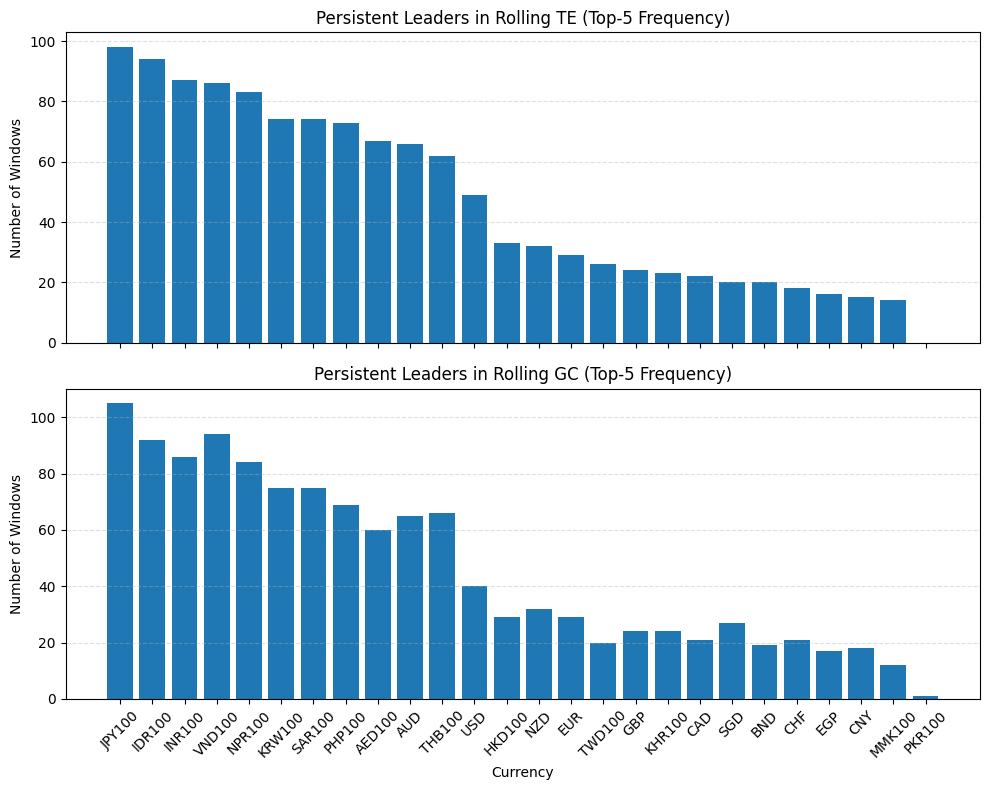


--- Top Persistent Leaders: TE ---
Currency  Occurrences  Persistence_Ratio Method
  JPY100           98           0.406639     TE
  IDR100           94           0.390041     TE
  INR100           87           0.360996     TE
  VND100           86           0.356846     TE
  NPR100           83           0.344398     TE
  KRW100           74           0.307054     TE
  SAR100           74           0.307054     TE
  PHP100           73           0.302905     TE
  AED100           67           0.278008     TE
     AUD           66           0.273859     TE

--- Top Persistent Leaders: GC ---
Currency  Occurrences  Persistence_Ratio Method
  JPY100          105           0.435685     GC
  VND100           94           0.390041     GC
  IDR100           92           0.381743     GC
  INR100           86           0.356846     GC
  NPR100           84           0.348548     GC
  KRW100           75           0.311203     GC
  SAR100           75           0.311203     GC
  PHP100        

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# =========================================================
# Persistent Leaders (Top-k frequency) for TE and GC
# =========================================================

top_k = 5  # adjust as desired

def compute_persistent_leaders(df_rolling, method_name, top_k=5):
    leader_counts = Counter()

    for date, group in df_rolling.groupby('Date'):
        leaders = (
            group.groupby('Source')['Lead_Strength']
            .mean()
            .sort_values(ascending=False)
            .head(top_k)
            .index
        )
        for currency in leaders:
            leader_counts[currency] += 1

    df_persistent = pd.DataFrame(
        [{'Currency': ccy, 'Occurrences': count} for ccy, count in leader_counts.items()]
    ).sort_values('Occurrences', ascending=False)

    total_windows = df_rolling['Date'].nunique()
    df_persistent['Persistence_Ratio'] = df_persistent['Occurrences'] / total_windows
    df_persistent['Method'] = method_name

    return df_persistent

# Compute for both methods
df_persistent_te = compute_persistent_leaders(df_rolling_te, method_name='TE', top_k=top_k)
df_persistent_gc = compute_persistent_leaders(df_rolling_gc, method_name='GC', top_k=top_k)

# Align currencies so both plots use the same ordering
all_currencies = sorted(set(df_persistent_te['Currency']).union(set(df_persistent_gc['Currency'])))

te_plot = (
    df_persistent_te.set_index('Currency')
    .reindex(all_currencies)
    .fillna({'Occurrences': 0, 'Persistence_Ratio': 0})
    .reset_index()
)

gc_plot = (
    df_persistent_gc.set_index('Currency')
    .reindex(all_currencies)
    .fillna({'Occurrences': 0, 'Persistence_Ratio': 0})
    .reset_index()
)

# Sort by TE occurrences, then GC occurrences for a stable visual order
order_df = pd.DataFrame({
    'Currency': all_currencies,
    'TE_Occ': te_plot.set_index('Currency').loc[all_currencies, 'Occurrences'].values,
    'GC_Occ': gc_plot.set_index('Currency').loc[all_currencies, 'Occurrences'].values
}).sort_values(['TE_Occ', 'GC_Occ'], ascending=False)

plot_order = order_df['Currency'].tolist()

te_plot = te_plot.set_index('Currency').loc[plot_order].reset_index()
gc_plot = gc_plot.set_index('Currency').loc[plot_order].reset_index()

# =========================================================
# Plot: TE on top, GC below
# =========================================================

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].bar(te_plot['Currency'], te_plot['Occurrences'])
axes[0].set_title(f'Persistent Leaders in Rolling TE (Top-{top_k} Frequency)')
axes[0].set_ylabel('Number of Windows')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].bar(gc_plot['Currency'], gc_plot['Occurrences'])
axes[1].set_title(f'Persistent Leaders in Rolling GC (Top-{top_k} Frequency)')
axes[1].set_ylabel('Number of Windows')
axes[1].set_xlabel('Currency')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional tables
print("\n--- Top Persistent Leaders: TE ---")
print(df_persistent_te.head(10).to_string(index=False))

print("\n--- Top Persistent Leaders: GC ---")
print(df_persistent_gc.head(10).to_string(index=False))

The results reveal a highly consistent set of persistent leaders across both transfer entropy (TE) and Granger causality (GC), reinforcing the earlier finding that the system's structure is largely stable and predominantly linear. In particular, JPY100 stands out as the dominant and most persistent driver, appearing in the top-$k$ set in over 40% of all windows under both methods. This indicates that the Japanese yen consistently exerts influence on other currencies across a wide range of market conditions, rather than only during isolated periods.

A second tier of persistent leaders emerges from emerging and regional Asian currencies, including IDR100, INR100, VND100, and NPR100. These currencies appear frequently in the top-$k$ set, suggesting that influence within the system is not solely driven by traditional major currencies, but also reflects regional dynamics and interconnectedness within emerging markets. Their persistence indicates that these currencies repeatedly act as sources of predictive information, potentially due to shared economic linkages, policy environments, or coordinated market movements.

The close alignment between TE and GC rankings is again notable. The same currencies appear with similar frequencies, and the ordering is largely preserved, with only minor differences (e.g., THB100 appearing in GC but not TE's top set). This further supports the interpretation that the dominant influence relationships are robust across methodologies, and that nonlinear effects do not materially alter the identification of persistent leaders in this dataset.

Economically, these findings suggest that the global FX network exhibits a core-periphery structure, where a small set of currencies consistently act as system drivers, while others respond more passively. The persistence measure adds an important temporal dimension to this interpretation: it identifies not just who is influential, but who remains influential over time, making these currencies particularly relevant for monitoring systemic dynamics and potential transmission channels of shocks.

## Analysis 2: Leader Rank Dynamics Over Time

We now examine how the leadership structure evolves across rolling windows by tracking the **rank of each currency** over time. For each window, currencies are ranked by their average outgoing influence, producing a complete ordering from strongest to weakest. These rankings are then visualized as a “fabric plot,” where each currency is placed on the vertical axis (in alphabetical order), time progresses along the horizontal axis, and color encodes the relative rank.

This analysis differs from the previous one on persistent leaders. While persistence measures **how often** a currency appears among the top-$k$ leaders over the full sample, the present approach captures **the full ranking at each point in time**. It therefore reveals not only whether a currency is influential, but also **how its relative position evolves**, including gradual shifts and abrupt changes in leadership.

Economically, this representation highlights periods of **stability**, where currencies maintain consistent ranks over extended intervals, as well as periods of **reorganization**, where rankings change rapidly across the system. Such patterns may reflect shifts in global and regional dynamics, including changes in monetary policy, capital flows, or market sentiment.

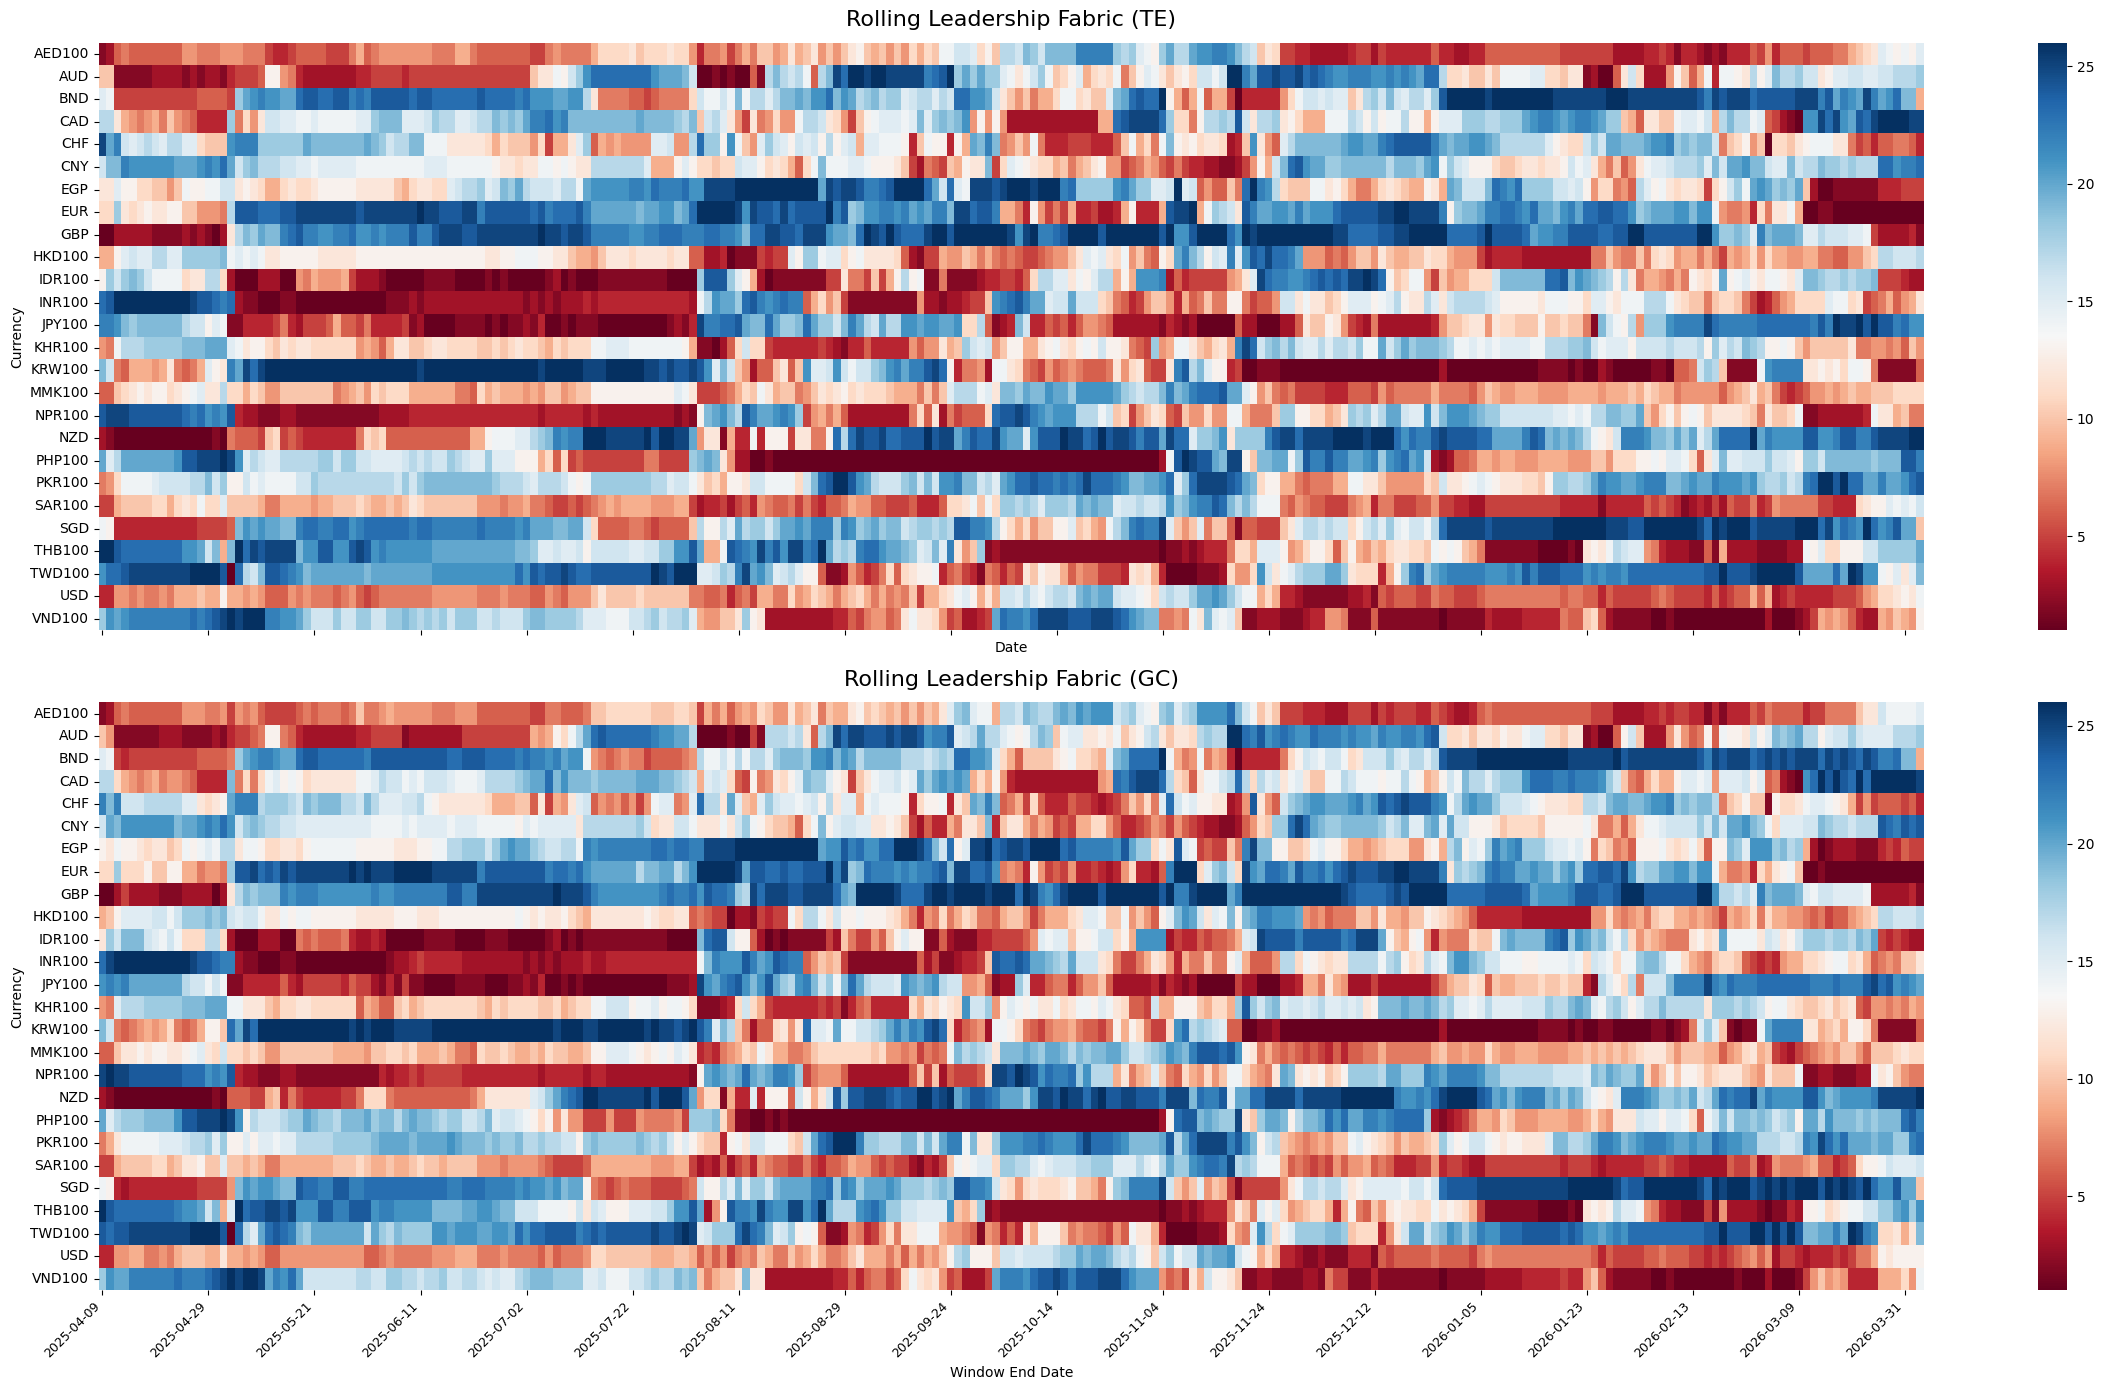

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# Build rolling rank matrices
# =========================================================

def build_rank_fabric(df_rolling, method_name):
    # Average outgoing influence by Date x Source
    df_avg = (
        df_rolling
        .groupby(['Date', 'Source'], as_index=False)['Lead_Strength']
        .mean()
        .rename(columns={'Source': 'Currency', 'Lead_Strength': 'Average_Lead_Strength'})
    )

    # Rank within each date: 1 = strongest
    df_avg['Rank'] = (
        df_avg
        .groupby('Date')['Average_Lead_Strength']
        .rank(method='first', ascending=False)
        .astype(int)
    )

    # Pivot to fabric form
    fabric = df_avg.pivot(index='Currency', columns='Date', values='Rank')

    # Alphabetical order top to bottom
    fabric = fabric.sort_index()

    return fabric

fabric_te = build_rank_fabric(df_rolling_te, method_name='TE')
fabric_gc = build_rank_fabric(df_rolling_gc, method_name='GC')

# Ensure dates are sorted
fabric_te = fabric_te.reindex(sorted(fabric_te.columns), axis=1)
fabric_gc = fabric_gc.reindex(sorted(fabric_gc.columns), axis=1)

# =========================================================
# Plot fabric panels
# =========================================================

fig, axes = plt.subplots(2, 1, figsize=(24, 14), sharex=True)

# Discrete-ish 26-rank color display
cmap = 'RdBu'

for ax, fabric, title in [
    (axes[0], fabric_te, 'Rolling Leadership Fabric (TE)'),
    (axes[1], fabric_gc, 'Rolling Leadership Fabric (GC)')
]:
    sns.heatmap(
        fabric,
        ax=ax,
        cmap=cmap,
        center=13.5,   # midpoint of 1–26
        vmin=1,
        vmax=26,
    )

    # Show dates every ~14 windows to avoid crowding
    n = 14
    xticks = np.arange(0, fabric.shape[1], n)
    xticklabels = [pd.to_datetime(fabric.columns[i]).strftime('%Y-%m-%d') for i in xticks]

    ax.set_xticks(xticks + 0.5)
    ax.set_xticklabels(xticklabels, rotation=45, ha='right', fontsize=9)

    ax.set_ylabel('Currency')
    ax.set_title(title, fontsize=16, pad=12)

axes[1].set_xlabel('Window End Date')

plt.tight_layout()
plt.show()

## Interpretation of Rolling Leadership Fabric (TE vs GC)

The fabric plots provide a time-resolved view of the **relative leadership rankings** of currencies, where color encodes rank from 1 (strongest leader) to 26 (weakest). Blue shades correspond to higher ranks (weaker leadership), while red shades correspond to lower ranks (stronger leadership), given the current color orientation.

A first key observation is the presence of **horizontal bands of consistent color**, indicating currencies whose ranks remain relatively stable over extended periods. For instance, certain currencies (e.g., JPY100 and EUR) exhibit prolonged stretches of strong leadership (reddish tones), consistent with their identification as persistent leaders in the earlier analysis. This confirms that their influence is not episodic but sustained across time.

Second, there are clear **temporal regime shifts**, visible as abrupt changes in color across many currencies at similar points in time. These transitions suggest periods where the global FX influence structure reorganizes. Around mid-sample, for example, several currencies simultaneously shift from weaker to stronger leadership (or vice versa), indicating a systemic reordering rather than isolated changes.

Third, the **co-movement of ranks across groups of currencies** is evident. Clusters of currencies tend to transition together, reflecting underlying regional or economic linkages. This supports the earlier interpretation of a **core-periphery or regional structure**, where groups of currencies jointly gain or lose influence.

Comparing the TE and GC panels, the overall patterns are strikingly similar. The same currencies tend to occupy similar rank regions, and regime shifts occur at approximately the same times. This reinforces the conclusion that the dominant structure of influence is largely **linear**, as both the nonlinear (TE) and linear (GC) methods recover nearly identical dynamics.

Finally, the plots highlight an important distinction from persistence analysis. While persistence identifies currencies that are frequently influential, the fabric reveals **how their influence evolves over time**, including periods of strengthening, weakening, and transition. In this sense, the fabric captures the **temporal geometry of influence**, not just its frequency.

## Alternative View: Standardized Leadership Fabric (Z-Score)

The next cell presents an alternative version of the previous fabric plot. Instead of displaying the **rank** of each currency at each date, we display how far each currency’s influence deviates from the average influence of all currencies at that same date.

For each date, we first compute the average outgoing influence for every currency. We then compute the mean and standard deviation of these values across all currencies for that date, and express each currency’s value as a z-score:

\begin{equation}
z_i = \frac{x_i - \mu}{\sigma},
\end{equation}

where $x_i$ is the average outgoing influence of currency $i$, $\mu$ is the mean across all currencies at that date, and $\sigma$ is the corresponding standard deviation.

This transformation replaces **ranking** with **deviation from the average**. A positive value indicates that a currency is more influential than the average at that date, while a negative value indicates that it is less influential.

As a result, the fabric now highlights **how strongly a currency stands out relative to others at each point in time**, rather than simply its position in an ordered list. This makes it easier to identify periods where influence is unusually concentrated or unusually balanced, and to detect shifts in how influence is distributed across the system.

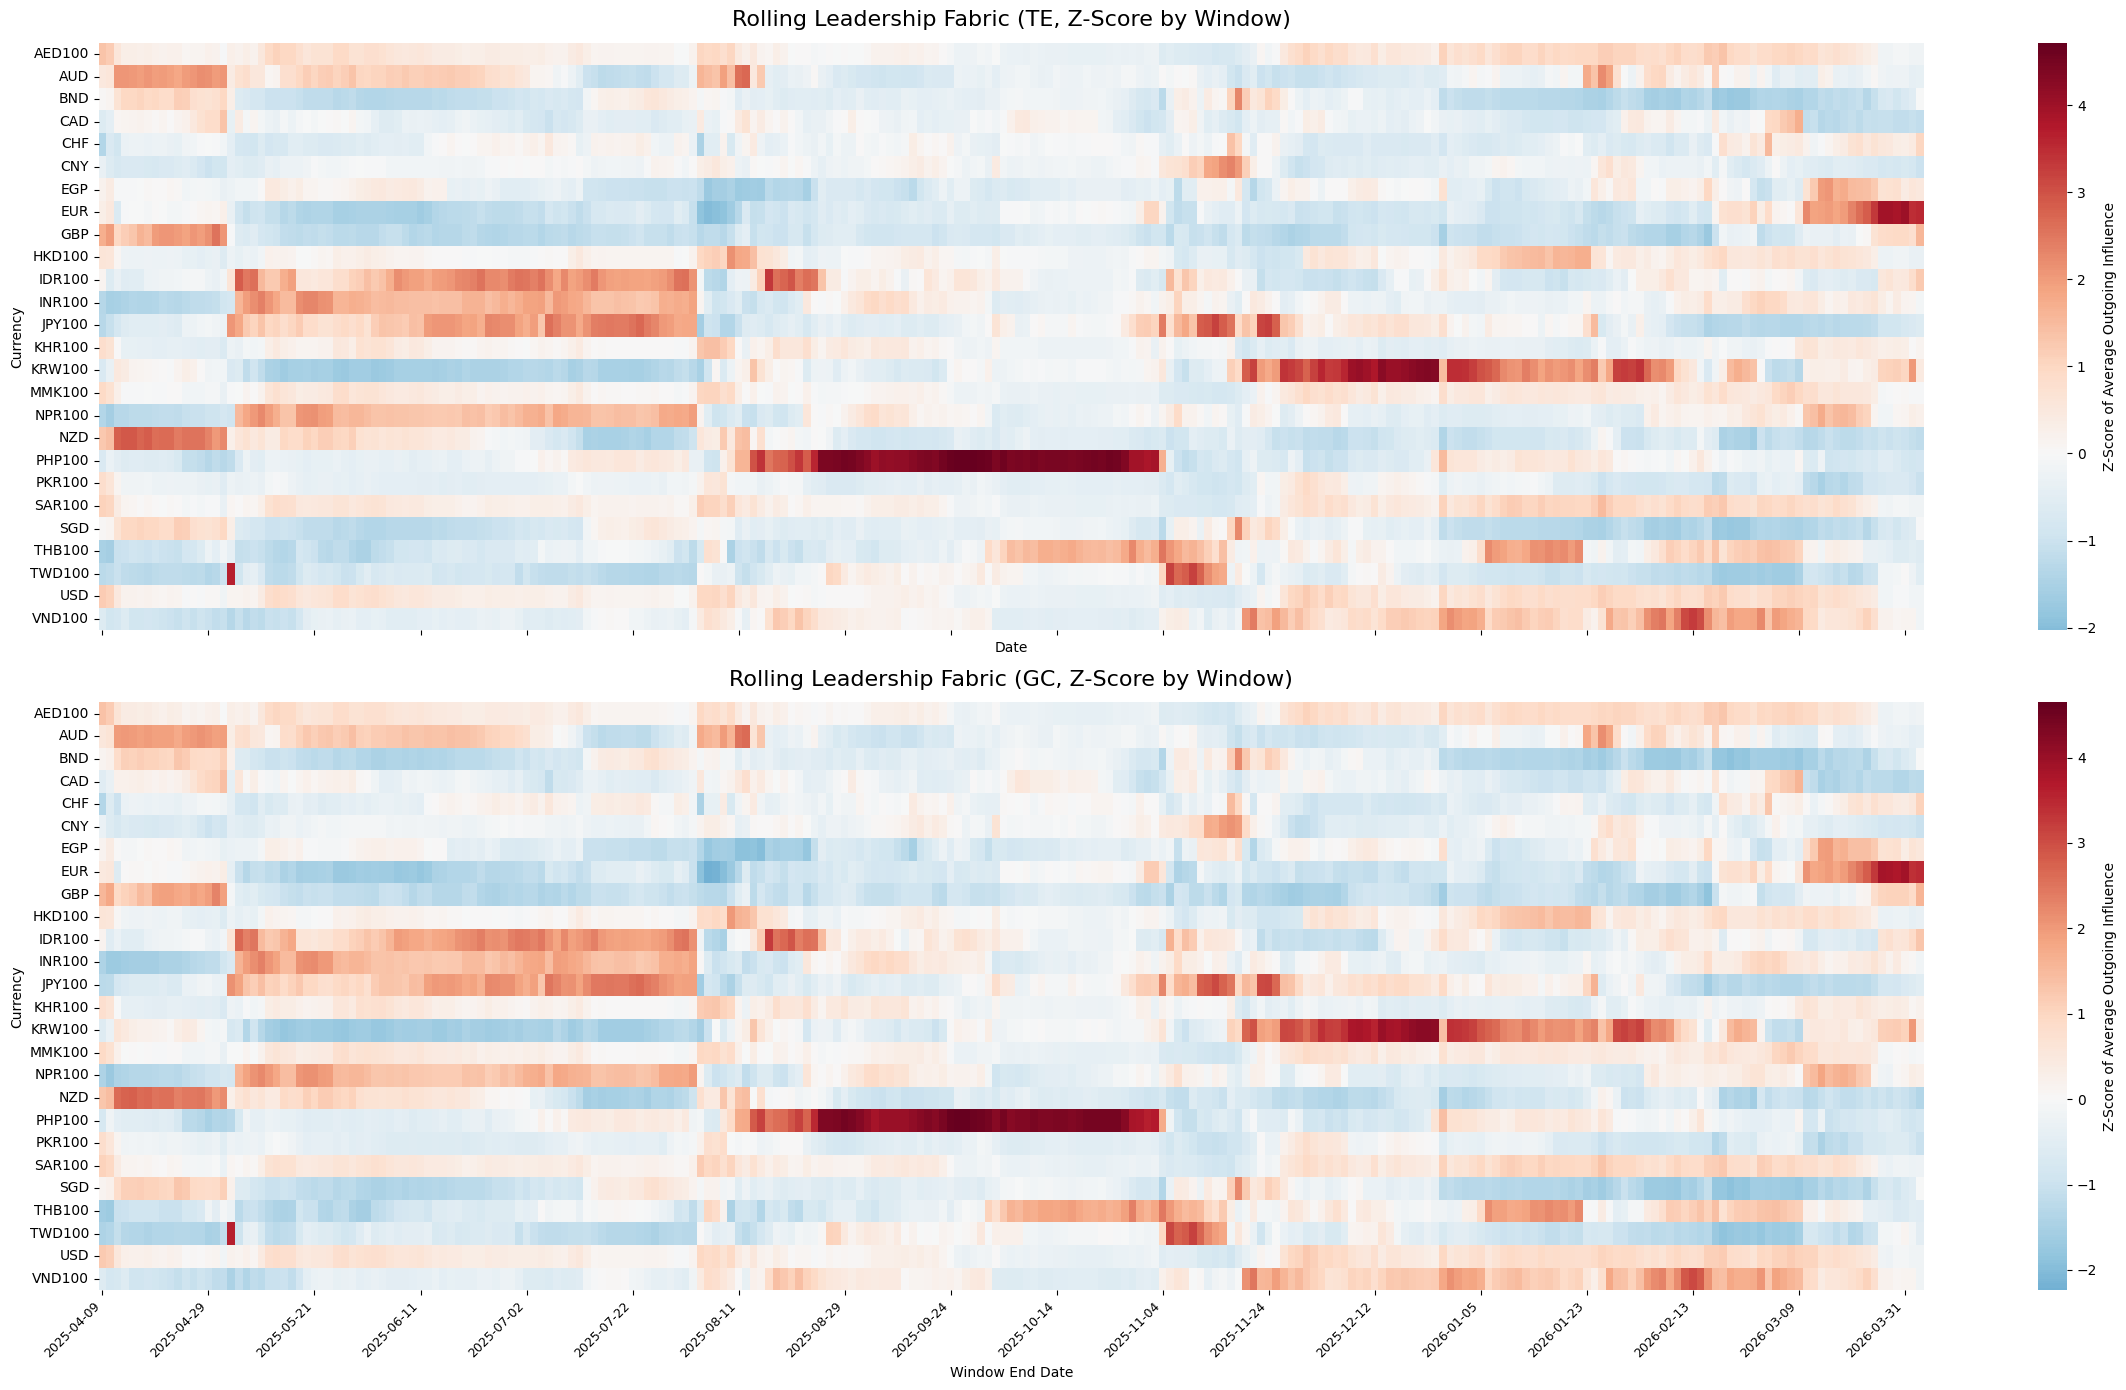

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# Build rolling z-score fabrics for TE and GC
# =========================================================

def build_zscore_fabric(df_rolling):
    # 1. Average outgoing influence by Date x Source
    df_avg = (
        df_rolling
        .groupby(['Date', 'Source'], as_index=False)['Lead_Strength']
        .mean()
        .rename(columns={'Source': 'Currency', 'Lead_Strength': 'Average_Lead_Strength'})
    )

    # 2. Cross-sectional z-score within each window
    df_avg['Window_Mean'] = df_avg.groupby('Date')['Average_Lead_Strength'].transform('mean')
    df_avg['Window_Std'] = df_avg.groupby('Date')['Average_Lead_Strength'].transform('std')

    # Guard against zero std
    df_avg['Window_Std'] = df_avg['Window_Std'].replace(0, np.nan)

    df_avg['Z_Score'] = (
        (df_avg['Average_Lead_Strength'] - df_avg['Window_Mean']) / df_avg['Window_Std']
    )

    # 3. Pivot to fabric form
    fabric = df_avg.pivot(index='Currency', columns='Date', values='Z_Score')

    # Alphabetical order top to bottom
    fabric = fabric.sort_index()

    # Ensure dates are sorted
    fabric = fabric.reindex(sorted(fabric.columns), axis=1)

    return fabric

fabric_z_te = build_zscore_fabric(df_rolling_te)
fabric_z_gc = build_zscore_fabric(df_rolling_gc)

# =========================================================
# Plot TE and GC z-score fabrics
# =========================================================

fig, axes = plt.subplots(2, 1, figsize=(24, 14), sharex=True)

for ax, fabric, title in [
    (axes[0], fabric_z_te, 'Rolling Leadership Fabric (TE, Z-Score by Window)'),
    (axes[1], fabric_z_gc, 'Rolling Leadership Fabric (GC, Z-Score by Window)')
]:
    sns.heatmap(
        fabric,
        ax=ax,
        cmap='RdBu_r',
        center=0,
        linewidths=0,
        cbar=True,
        cbar_kws={'label': 'Z-Score of Average Outgoing Influence'}
    )

    # Show dates every ~14 windows to avoid crowding
    n = 14
    xticks = np.arange(0, fabric.shape[1], n)
    xticklabels = [pd.to_datetime(fabric.columns[i]).strftime('%Y-%m-%d') for i in xticks]

    ax.set_xticks(xticks + 0.5)
    ax.set_xticklabels(xticklabels, rotation=45, ha='right', fontsize=9)

    ax.set_ylabel('Currency')
    ax.set_title(title, fontsize=16, pad=12)

axes[1].set_xlabel('Window End Date')

plt.tight_layout()
plt.show()

# Optional: keep tidy long-form z-score tables for later use
df_z_te = (
    fabric_z_te
    .stack()
    .reset_index()
)
df_z_te.columns = ['Currency', 'Date', 'Z_Score']

df_z_gc = (
    fabric_z_gc
    .stack()
    .reset_index()
)
df_z_gc.columns = ['Currency', 'Date', 'Z_Score']

## Interpretation of Rolling Leadership Fabric (Z-Score Standardization)

The z-score–standardized fabric conveys essentially the same structure as the ranking-based fabric, but expressed in terms of **deviation from the average** rather than ordinal position. The same currencies emerge as influential during similar periods, and the same regime shifts are visible across time.

The main difference is interpretational: instead of showing who ranks higher or lower, the z-score version highlights **how strongly** a currency deviates from the system-wide average at each date. As such, it reinforces the earlier observations while providing a complementary, scale-adjusted view of the same underlying dynamics.

In addition, several distinct regime shifts can be identified visually in the fabric. These occur at approximate dates where the relative influence of currencies changes abruptly and in a coordinated manner, suggesting system-wide reorganization rather than isolated movements. The key periods are:

- **Late July to early August 2025**: This period plausibly reflects shifts in expectations surrounding monetary policy in Japan, particularly changes in yield dynamics or intervention signals affecting the Japanese yen. Given the yen’s role in global funding and carry trades, such adjustments can propagate broadly across the FX network.

- **Early November 2025 (around November 4)**: This aligns with a typical cluster of major macroeconomic events, including policy decisions by the Federal Reserve and associated repricing of the US dollar. Such events often trigger coordinated adjustments across currencies, leading to a reordering of influence relationships.

- **End-2025 to early 2026**: This period likely reflects year-end effects, including portfolio rebalancing, liquidity shifts, and institutional repositioning. These factors can induce temporary but significant changes in the structure of influence across currencies.

It is important to emphasize that these interpretations are **hypothesis-driven rather than definitive**. The fabric identifies *when* structural changes occur, while the attribution to macroeconomic events should be validated through external data. Nonetheless, the alignment of these shifts with known periods of heightened macro activity provides a consistent and economically plausible explanation for the observed reorganization of the network.

## Analysis 3: Temporal Stability, Regime Shifts, and Systemic Concentration

In the previous two analyses, the focus was on individual currencies—either in terms of their persistence as leaders or their relative ranking over time. We now shift attention to the system as a whole.

We now move to a system-level analysis of how the influence network evolves over time. Rather than focusing on individual currencies, this analysis examines **how the overall structure of the network changes from one period to the next**.

To do so, we construct a measure of **network change** by comparing the influence structure at consecutive dates. At each date, the network can be represented as a collection of influence measures across all currency pairs. By computing a similarity (or distance) between the network at time $t$ and time $t-1$, we obtain a time series that captures the degree of structural change. Periods of low change correspond to **stable regimes**, where the network configuration is largely unchanged, while spikes in change indicate **regime shifts**, where the pattern of influence is reorganized.

This system-level perspective is complemented by an analysis of the **absorption ratio (AR)**, which measures the degree of concentration in the system. The absorption ratio is defined as the fraction of total variance explained by a small number of leading principal components, and can be written as:
\begin{equation}
\text{AR} = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{N} \lambda_i},
\end{equation}
where $\lambda_i$ are the eigenvalues of the covariance matrix, ordered from largest to smallest, and $k$ is a chosen number of dominant factors.

The absorption ratio provides a measure of **systemic coupling**. High values indicate that a large portion of the system’s variation is driven by a few common factors, suggesting a tightly connected or fragile system. Low values indicate more dispersed dynamics, where influence is distributed across many independent components.

By combining these two perspectives, we obtain a richer characterization of system behavior:
- The **network change metric** captures *when* the system reorganizes,
- The **absorption ratio** captures *how concentrated* the system is.

Together, they allow us to distinguish between different regimes. For example, a period of low network change and high absorption ratio indicates a **stable but tightly coupled system**, whereas simultaneous spikes in both measures may signal a **systemic regime shift**. This joint analysis therefore provides insight into both the **dynamics and the fragility** of the global FX influence network.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Analysis 3: Temporal Stability / Regime Shifts + Absorption Ratio
# =========================================================

# Assumptions:
# - df_rolling_te and df_rolling_gc are already loaded
# - df_returns is already prepared
# - window_size is already defined (use 63 if not)
# - available_cols is already defined

if 'window_size' not in globals():
    window_size = 63

# ---------------------------------------------------------
# 1. Build date-by-edge matrices for TE and GC
# ---------------------------------------------------------

def build_edge_matrix(df_rolling):
    edge_matrix = (
        df_rolling
        .assign(Edge=lambda x: x['Source'] + '→' + x['Target'])
        .pivot(index='Date', columns='Edge', values='Lead_Strength')
        .sort_index()
    )
    return edge_matrix

edge_te = build_edge_matrix(df_rolling_te)
edge_gc = build_edge_matrix(df_rolling_gc)

# ---------------------------------------------------------
# 2. Consecutive-state similarity and change metrics
#    Similarity = correlation between full edge vectors at t and t-1
#    Change = 1 - similarity
# ---------------------------------------------------------

def compute_network_change(edge_matrix, method_name):
    dates = edge_matrix.index.tolist()
    records = []

    for i in range(1, len(dates)):
        prev_date = dates[i - 1]
        curr_date = dates[i]

        prev_vec = edge_matrix.loc[prev_date]
        curr_vec = edge_matrix.loc[curr_date]

        valid = prev_vec.notna() & curr_vec.notna()
        prev_vals = prev_vec[valid].astype(float).values
        curr_vals = curr_vec[valid].astype(float).values

        if len(prev_vals) < 2:
            similarity = np.nan
        else:
            if np.std(prev_vals) == 0 or np.std(curr_vals) == 0:
                similarity = np.nan
            else:
                similarity = np.corrcoef(prev_vals, curr_vals)[0, 1]

        records.append({
            'Date': pd.to_datetime(curr_date),
            'Similarity': similarity,
            'Change': np.nan if pd.isna(similarity) else 1 - similarity,
            'Method': method_name
        })

    return pd.DataFrame(records)

df_change_te = compute_network_change(edge_te, method_name='TE')
df_change_gc = compute_network_change(edge_gc, method_name='GC')

# Optional smoothing
smooth_window = 5
df_change_te['Change_Smoothed'] = df_change_te['Change'].rolling(smooth_window, min_periods=1).mean()
df_change_gc['Change_Smoothed'] = df_change_gc['Change'].rolling(smooth_window, min_periods=1).mean()

In [30]:
# ---------------------------------------------------------
# 3. Rolling Absorption Ratio (AR)
#    AR = sum of top-k eigenvalues / sum of all eigenvalues
# ---------------------------------------------------------

num_eigs = 3  # you may adjust this

# Build the list of window end dates exactly as in the rolling TE/GC runs
rolling_dates = pd.to_datetime(df_forex[date_col].iloc[window_size:window_size + len(df_returns) - window_size])

ar_records = []

for start_idx in range(len(df_returns) - window_size):
    end_idx = start_idx + window_size
    end_date = pd.to_datetime(df_forex[date_col].iloc[end_idx])

    window_df = df_returns.iloc[start_idx:end_idx].copy()

    # Covariance matrix
    cov_mat = window_df.cov().values

    # Eigenvalues, descending
    eigvals = np.linalg.eigvalsh(cov_mat)
    eigvals = np.sort(np.real(eigvals))[::-1]

    total_var = eigvals.sum()
    ar_value = np.nan if total_var <= 0 else eigvals[:num_eigs].sum() / total_var

    ar_records.append({
        'Date': end_date,
        'Absorption_Ratio': ar_value
    })

df_ar = pd.DataFrame(ar_records).sort_values('Date').reset_index(drop=True)
df_ar['AR_Smoothed'] = df_ar['Absorption_Ratio'].rolling(smooth_window, min_periods=1).mean()

In [31]:
# ---------------------------------------------------------
# 4. Merge for convenience
# ---------------------------------------------------------

df_regime = (
    df_change_te[['Date', 'Change', 'Change_Smoothed']]
    .rename(columns={
        'Change': 'TE_Change',
        'Change_Smoothed': 'TE_Change_Smoothed'
    })
    .merge(
        df_change_gc[['Date', 'Change', 'Change_Smoothed']].rename(columns={
            'Change': 'GC_Change',
            'Change_Smoothed': 'GC_Change_Smoothed'
        }),
        on='Date',
        how='outer'
    )
    .merge(df_ar[['Date', 'Absorption_Ratio', 'AR_Smoothed']], on='Date', how='outer')
    .sort_values('Date')
    .reset_index(drop=True)
)

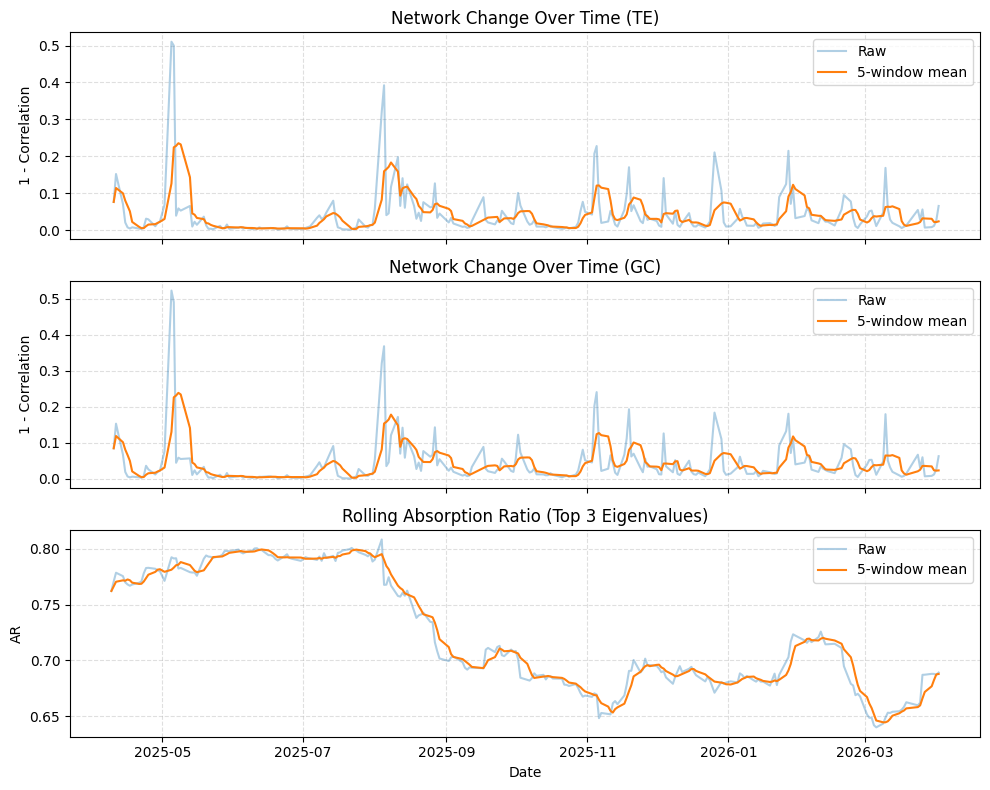

In [49]:
# ---------------------------------------------------------
# 5. Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(df_regime['Date'], df_regime['TE_Change'], alpha=0.35, label='Raw')
axes[0].plot(df_regime['Date'], df_regime['TE_Change_Smoothed'], label=f'{smooth_window}-window mean')
axes[0].set_title('Network Change Over Time (TE)')
axes[0].set_ylabel('1 - Correlation')
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].legend()

axes[1].plot(df_regime['Date'], df_regime['GC_Change'], alpha=0.35, label='Raw')
axes[1].plot(df_regime['Date'], df_regime['GC_Change_Smoothed'], label=f'{smooth_window}-window mean')
axes[1].set_title('Network Change Over Time (GC)')
axes[1].set_ylabel('1 - Correlation')
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].legend()

axes[2].plot(df_regime['Date'], df_regime['Absorption_Ratio'], alpha=0.35, label='Raw')
axes[2].plot(df_regime['Date'], df_regime['AR_Smoothed'], label=f'{smooth_window}-window mean')
axes[2].set_title(f'Rolling Absorption Ratio (Top {num_eigs} Eigenvalues)')
axes[2].set_ylabel('AR')
axes[2].set_xlabel('Date')
axes[2].grid(True, linestyle='--', alpha=0.4)
axes[2].legend()

plt.tight_layout()
plt.show()

## Interpretation of Network Change and Absorption Ratio

The notion of **network change** can be understood in simple terms as follows: at each date, the entire system of relationships—who influences whom and by how much—is represented as a collection of numbers. To measure how the system evolves, we compare this collection at time $t$ with that at time $t-1$. If the two are very similar, the network is said to be stable; if they differ substantially, the network has undergone a structural change. In the implementation above, this is done by computing the correlation between the two sets of relationships and defining network change as $1 - \text{correlation}$. Values close to zero therefore indicate stability, while spikes indicate **reorganization of the influence structure**.

The results show that both the transfer entropy (TE) and Granger causality (GC) measures produce nearly identical patterns of network change. This reinforces the earlier conclusion that the dominant structure of dependencies in the dataset is largely linear. Across the sample, the network exhibits long stretches of **low change**, indicating that the pattern of influence among currencies is generally stable. These periods are punctuated by **sharp spikes**, which correspond to regime shifts where the configuration of influence is abruptly rearranged. Importantly, these spikes are short-lived, suggesting that the system tends to **re-stabilize quickly after disturbances**.

The absorption ratio (AR) provides a complementary perspective. While network change captures *how the structure evolves*, the absorption ratio measures *how concentrated the system is*. Higher values indicate that a large portion of the system’s variation is driven by a small number of dominant factors, implying a more tightly coupled system. Lower values indicate that influence is more dispersed across currencies.

In the early part of the sample, the absorption ratio is relatively high and increasing, indicating a **tightly coupled system**. During this period, spikes in network change coincide with a high degree of concentration, suggesting that structural shifts are likely to be **system-wide rather than localized**. In contrast, the middle portion of the sample shows a decline in the absorption ratio, accompanied by relatively low levels of network change. This points to a **more diffuse and stable system**, where influence is spread across currencies and less prone to large-scale reorganization. In the later part of the sample, the absorption ratio fluctuates at moderate levels, and the network exhibits smaller, more frequent changes, indicating **localized adjustments rather than broad systemic shifts**.

Taken together, these results highlight the importance of viewing the system through both lenses. Network change identifies *when* the structure shifts, while the absorption ratio indicates *how concentrated and potentially fragile* the system is at those times. This combined perspective allows us to distinguish between stable regimes, tightly coupled but fragile configurations, and periods of structural transition in the global FX influence network.

### Selection of $k$ for Absorption Ratio

We have used $k = 3$ for the number of eigenvalues in the absorption ratio (AR) computation above. This choice is not arbitrary, but is guided by **Random Matrix Theory (RMT)**.

Under RMT, the eigenvalues of a covariance (or correlation) matrix can be separated into two groups: those that arise from **noise**, and those that represent **true underlying structure (signal)**. The theoretical upper bound for noise eigenvalues is given by the Marčenko–Pastur limit:
\begin{equation}
\lambda_{\max}^{\text{MP}} = (1 + \sqrt{q})^2,
\end{equation}
where $q = \frac{N}{T}$, with $N$ being the number of assets and $T$ the number of observations.

Eigenvalues exceeding this threshold are interpreted as **informative factors**, while those below are treated as noise. In our case, exactly three eigenvalues lie above $\lambda_{\max}^{\text{MP}}$, implying that the system is effectively driven by **three dominant factors**.

Accordingly, we set $k = 3$ in the absorption ratio calculation, so that AR captures the proportion of variance explained by these **signal-bearing components**, rather than including noise-dominated dimensions.

N = 26, T = 304, q = 0.0855
MP upper bound (lambda_max) = 1.6704
Number of eigenvalues above noise (k) = 3


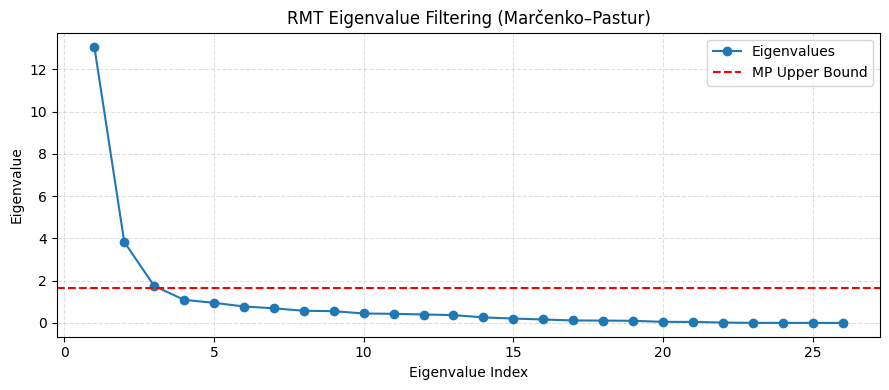

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# RMT (Marčenko–Pastur) Threshold for k
# =========================================================

# Use correlation matrix (standard practice for RMT)
corr_mat = df_returns.corr().values

# Dimensions
T = df_returns.shape[0]   # number of observations
N = df_returns.shape[1]   # number of assets

q = N / T

# Eigenvalues (descending)
eigvals = np.linalg.eigvalsh(corr_mat)
eigvals = np.sort(np.real(eigvals))[::-1]

# MP bounds (for correlation matrix, sigma^2 = 1)
lambda_max = (1 + np.sqrt(q))**2
lambda_min = (1 - np.sqrt(q))**2

# Determine k
k_rmt = np.sum(eigvals > lambda_max)

print(f"N = {N}, T = {T}, q = {q:.4f}")
print(f"MP upper bound (lambda_max) = {lambda_max:.4f}")
print(f"Number of eigenvalues above noise (k) = {k_rmt}")

# =========================================================
# Plot eigenvalues with MP threshold
# =========================================================

plt.figure(figsize=(9, 4))

plt.plot(range(1, N + 1), eigvals, marker='o', label='Eigenvalues')
plt.axhline(y=lambda_max, color='red', linestyle='--', label='MP Upper Bound')

plt.title('RMT Eigenvalue Filtering (Marčenko–Pastur)')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

## Interpretation of RMT-Based Factor Selection

The Random Matrix Theory (RMT) analysis yields $N = 26$ assets and $T = 304$ observations, giving $q = N/T = 0.0855$. The corresponding Marčenko-Pastur upper bound is $\lambda_{\max}^{\text{MP}} = 1.6704$. Only three eigenvalues exceed this threshold, implying that the remaining eigenvalues are consistent with noise.

This result indicates that the system is effectively **low-dimensional**, with the majority of its variation driven by **three dominant factors**. These factors can be interpreted as the primary sources of common movement across currencies, while the remaining components reflect idiosyncratic or weakly structured fluctuations.

Note that this selection of $k = 3$ is based on the **full-sample correlation structure**, rather than a rolling computation. The purpose of the RMT step is to identify the **intrinsic dimensionality of the system**, which is assumed to be relatively stable over time. Applying RMT on a rolling basis would lead to **unstable and noisy estimates of $k$**, as the eigenvalue distribution is sensitive to sample size and short-term fluctuations. As such, a rolling RMT procedure would confound true structural changes with estimation noise.

Accordingly, we fix $k = 3$ across all periods in the rolling absorption ratio computation. This ensures that AR consistently measures the contribution of the same set of **signal-bearing factors**, allowing for meaningful comparison over time.

## Analysis 4: Eigenvector Centrality — Structural Importance in the Network

The previous analyses have focused on identifying which currencies are influential, how their rankings evolve over time, and when the overall system undergoes structural change. We now turn to a complementary perspective: **the structural position of each currency within the network**.

Eigenvector centrality (EC) provides a measure of importance that goes beyond direct influence. A currency is considered central not only if it influences others, but if it influences **currencies that are themselves influential**. In this sense, EC captures the idea of **second-order influence**, or influence that propagates through the network.

In a directed setting, two notions of centrality arise naturally. The first is **leader centrality**, derived from the right eigenvector of the influence matrix, which captures how strongly a currency contributes to the propagation of influence through the system. The second is **feedback centrality**, derived from the left eigenvector (or equivalently, the right eigenvector of the transpose), which captures how sensitive a currency is to influence originating from other central nodes.

By computing these measures on a rolling basis, we obtain a time series of centrality scores for each currency. This allows us to track how the **structural hubs of the network evolve over time**, and to distinguish between currencies that are locally influential and those that are embedded in the core of the global influence structure.

This analysis therefore complements the earlier results by identifying not just *who leads*, but *who sits at the center of the system’s influence topology*.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# =========================================================
# 1. Setup from df_rolling_te
# =========================================================

df = df_rolling_te.copy()
df['Date'] = pd.to_datetime(df['Date'])

all_currencies = sorted(set(df['Source']).union(set(df['Target'])))
n_curr = len(all_currencies)
curr_to_idx = {curr: i for i, curr in enumerate(all_currencies)}

leader_data = []
feedback_data = []
dates = []

# Group by Date → each is one "window"
for date, group in df.groupby('Date'):
    te_matrix = np.zeros((n_curr, n_curr))

    for _, row in group.iterrows():
        i = curr_to_idx[row['Source']]
        j = curr_to_idx[row['Target']]
        te_matrix[i, j] = row['Lead_Strength']

    dates.append(date)

    # --- Leader EC ---
    evals_r, evecs_r = np.linalg.eig(te_matrix)
    max_r = np.argmax(np.abs(evals_r))
    l_centrality = np.abs(evecs_r[:, max_r])
    l_centrality = l_centrality / l_centrality.sum() if l_centrality.sum() > 0 else l_centrality
    leader_data.append(l_centrality)

    # --- Feedback EC ---
    evals_l, evecs_l = np.linalg.eig(te_matrix.T)
    max_l = np.argmax(np.abs(evals_l))
    f_centrality = np.abs(evecs_l[:, max_l])
    f_centrality = f_centrality / f_centrality.sum() if f_centrality.sum() > 0 else f_centrality
    feedback_data.append(f_centrality)

# Build DataFrames
df_leader = pd.DataFrame(leader_data, columns=all_currencies, index=dates).sort_index()
df_feedback = pd.DataFrame(feedback_data, columns=all_currencies, index=dates).sort_index()

# =========================================================
# 2. Plot function
# =========================================================

def plot_ec_evolution(selected_coins, mode):
    plt.figure(figsize=(12, 5))
    data = df_leader if mode == 'Leader (Influence)' else df_feedback

    for coin in selected_coins:
        if coin in data.columns:
            plt.plot(data.index, data[coin], label=coin, linewidth=2.5)

    plt.title(f'Evolution of {mode} Centrality', fontsize=16)
    plt.ylabel('Normalized EC Score')
    plt.xlabel('Date')

    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()

# =========================================================
# 3. Widgets (clean defaults)
# =========================================================

default_selection = [c for c in ['USD', 'JPY100', 'EUR', 'GBP'] if c in all_currencies]

coin_selector = widgets.SelectMultiple(
    options=all_currencies,
    value=default_selection,
    description='Currencies:',
    rows=10
)

mode_selector = widgets.Dropdown(
    options=['Leader (Influence)', 'Feedback (Sensitivity)'],
    value='Leader (Influence)',
    description='EC Type:'
)

ui = widgets.HBox([coin_selector, mode_selector])
out = widgets.interactive_output(plot_ec_evolution, {
    'selected_coins': coin_selector,
    'mode': mode_selector
})

display(ui, out)

Output()

## Interpretation of Eigenvector Centrality Evolution (Selected Currencies)

The evolution of eigenvector centrality (EC) provides insight into the **structural importance** of currencies within the influence network. Unlike direct influence measures, EC reflects how well a currency is connected to other influential currencies, and therefore captures its role within the **core of the system**.

Over the sample period, the four selected currencies—USD, JPY100, EUR, and GBP—exhibit distinct patterns.

The USD displays relatively **stable centrality** throughout the period, with moderate fluctuations. It neither dominates nor disappears from the network core, suggesting that it serves as a **persistent structural anchor**. This is consistent with its role as a global reserve currency, maintaining continuous relevance even when not the most dominant source of influence.

The JPY100 shows **episodic spikes in centrality**, particularly around mid-2025 and again in late 2025. These spikes indicate periods where the yen becomes highly connected to other influential currencies, likely reflecting shifts in global funding conditions or policy expectations. However, these episodes are not sustained, and the yen’s centrality declines afterward, suggesting that its role is **event-driven rather than persistent**.

The EUR exhibits a notable **late-sample surge in centrality**, reaching the highest levels among the four currencies toward early 2026. This indicates a transition into a position of **dominant structural importance**, where the euro becomes deeply embedded in the network of influential relationships. Prior to this, its centrality remains moderate, implying a **regime-dependent rise in influence**.

The GBP shows relatively **low centrality for most of the sample**, with a gradual increase toward the end. This suggests that the pound is generally **peripheral to the core influence structure**, but becomes more relevant in the later period. The increase, while noticeable, does not reach the levels of EUR or JPY100 during their peak phases.

Taken together, these patterns highlight a dynamic structure in which:
- the USD remains a **stable core node**,  
- the JPY100 acts as a **cyclical or shock-driven hub**,  
- the EUR transitions into a **dominant central position late in the sample**, and  
- the GBP remains **secondary but becomes more engaged over time**.

This analysis reinforces the distinction between **direct influence** and **structural centrality**, showing that currencies may differ in their immediate impact versus their embeddedness within the broader network.

## Analysis 5: Dynamic Network Visualization — Global Causal Pulse

We now construct a dynamic visualization of the influence network to provide an intuitive, time-resolved view of how relationships evolve across currencies. While the previous analyses quantified influence, ranking, and structural change, this step allows us to **directly observe the network as it evolves over time**. We will restrict ourselves to the TE results only henceforth; the reader is invited to perform the same analyses using the GC results.

Now at each date, we represent the system as a directed graph, where nodes correspond to currencies and edges represent statistically significant influence relationships. To ensure that the visualization remains meaningful across time, we adopt an **adaptive thresholding approach**. Specifically, for each date $t$, we compute a threshold $\tau_t$ based on the cross-sectional distribution of influence strengths (`Lead_Strength`), and retain only edges exceeding this threshold.

For example, if the threshold is set at the **95th percentile**, this means that, at each date, only the top 5% strongest influence relationships are retained, while the remaining 95% are discarded. In other words, the graph focuses exclusively on the **most dominant links in that particular period**, regardless of the absolute magnitude of the underlying values.

This ensures that the visualization highlights the **strongest relationships relative to each period**, rather than relying on a fixed cutoff that may be inappropriate under changing market conditions.

As an alternative, the code also includes an option to retain the top $x\%$ of edges at each date. While this provides tighter control over graph sparsity, the default percentile-based thresholding is preferred, as it preserves the **temporal variation in network density**.

Node coloring is based on **net influence**, defined as total outgoing influence minus total incoming influence. This provides a simple measure of whether a currency acts as a net source or sink of influence at each point in time. The values are standardized within each frame to ensure visual comparability across dates.

Taken together, the resulting animation—referred to as the *Global Causal Pulse*—offers a compact representation of:
- how influence propagates across the system,  
- how network density and connectivity evolve, and  
- how leadership and structural roles shift over time.

This visualization complements the earlier quantitative analyses by providing a **direct and interpretable view of the system's dynamics**.

In [54]:
# import matplotlib as mpl
# mpl.rcParams['animation.embed_limit'] = 100.0  # 100 MB

# import matplotlib.pyplot as plt
# import networkx as nx
# import numpy as np
# import pandas as pd
# import matplotlib.animation as animation
# from IPython.display import HTML

# # =========================================================
# # 1. Parameters
# # =========================================================

# percentile = 95        # for adaptive tau_t
# top_pct = 5            # for alternative method
# use_percentile = True  # True = percentile, False = top-x%

# fps = 10
# all_nodes = sorted(list(cols_to_fix))
# pos = nx.circular_layout(all_nodes)

# # Ensure dates are sorted and consistent
# df = df_rolling_te.copy()
# df['Date'] = pd.to_datetime(df['Date'])
# plot_dates = sorted(df['Date'].unique())

# # Group once (efficient)
# grouped = dict(tuple(df.groupby('Date')))
# num_frames = len(plot_dates)

# fig, ax = plt.subplots(figsize=(9, 9))

# # =========================================================
# # 2. Update function
# # =========================================================

# def update(frame_idx):
#     ax.clear()

#     current_date = plot_dates[frame_idx]
#     window_df = grouped[current_date]

#     # --------------------------------------------
#     # Compute adaptive tau_t
#     # --------------------------------------------
#     lead_vals = window_df['Lead_Strength'].values

#     if use_percentile:
#         # --- Method 1: Percentile threshold ---
#         tau_t = np.percentile(lead_vals, percentile)
#     else:
#         # --- Method 2: Top-x% edges (alternative) ---
#         sorted_vals = np.sort(lead_vals)
#         cutoff_idx = int(len(sorted_vals) * (1 - top_pct / 100))
#         tau_t = sorted_vals[cutoff_idx] if cutoff_idx < len(sorted_vals) else sorted_vals[-1]

#     # --------------------------------------------
#     # Build graph
#     # --------------------------------------------
#     G = nx.DiGraph()
#     G.add_nodes_from(all_nodes)

#     for _, row in window_df.iterrows():
#         src, tgt = row['Source'], row['Target']
#         lead = row['Lead_Strength']
#         fb = row.get('Feedback_Strength', 0)

#     for _, row in window_df.iterrows():
#         src, tgt = row['Source'], row['Target']
#         lead = row['Lead_Strength']

#         if lead > tau_t:
#             G.add_edge(src, tgt, weight=lead)

#     # --------------------------------------------
#     # Node coloring: Net influence
#     # --------------------------------------------
#     out_strength = window_df.groupby('Source')['Lead_Strength'].sum()
#     in_strength = window_df.groupby('Target')['Lead_Strength'].sum()

#     net_series = out_strength.subtract(in_strength, fill_value=0)
#     net_series = net_series.reindex(all_nodes).fillna(0)

#     node_colors = net_series.values

#     # Optional normalization (recommended for visualization)
#     if np.std(node_colors) > 0:
#         node_colors = (node_colors - np.mean(node_colors)) / np.std(node_colors)

#     # --------------------------------------------
#     # Draw nodes
#     # --------------------------------------------
#     nx.draw_networkx_nodes(
#         G, pos, ax=ax,
#         node_size=750,
#         node_color=node_colors,
#         cmap='RdBu',
#         edgecolors='black',
#         linewidths=1.2
#     )

#     # --------------------------------------------
#     # Draw edges
#     # --------------------------------------------
#     if G.number_of_edges() > 0:
#         weights = [G[u][v]['weight'] * 10 for u, v in G.edges()]
#         nx.draw_networkx_edges(
#             G, pos, ax=ax,
#             edge_color='black',
#             alpha=0.7,
#             width=weights,
#             arrowsize=25,
#             arrowstyle='-|>',
#             connectionstyle='arc3,rad=0.1'
#         )

#     nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold')

#     # --------------------------------------------
#     # Title
#     # --------------------------------------------
#     ax.set_title(
#         f"Global Causal Pulse\nDate: {current_date.strftime('%Y-%m-%d')} | τₜ = {tau_t:.4f} | Edges = {G.number_of_edges()}",
#         fontsize=15,
#         fontweight='bold'
#     )

#     ax.axis('off')

# # =========================================================
# # 3. Animation
# # =========================================================

# ani = animation.FuncAnimation(
#     fig, update,
#     frames=num_frames,
#     interval=1000 / fps
# )

# plt.close()
# HTML(ani.to_jshtml())

### UNCOMMENT THIS CELL TO RUN AND SEE THE NETWORK EVOLUTION

In [53]:
# Save the animation to your local drive
ani.save('forex_causal_pulse.mp4', writer='ffmpeg', fps=10)

print("✅ Animation saved as forex_causal_pulse.mp4")

✅ Animation saved as forex_causal_pulse.mp4


### Dynamic Thresholding Diagnostic

This plot provides a visual overview of the distribution of `Lead_Strength` values over time. The blue dots represent all pairwise influence strengths at each date, while the orange lines show the first quartile, median, and third quartile. The red line indicates the threshold $\tau_t$ (e.g., the 95th percentile) used for filtering edges in the network visualization.

The purpose of this plot is simply to give a **visual sense of where the threshold lies relative to the distribution**, ensuring that it captures the strongest relationships in each period.

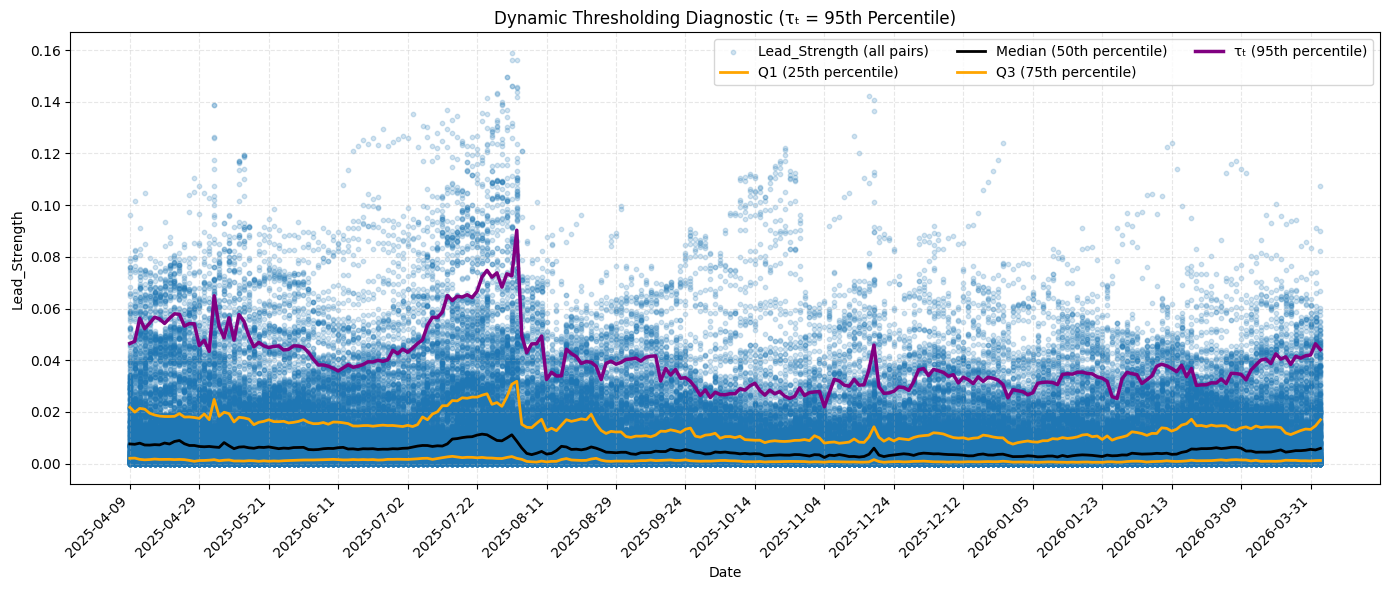

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Parameters
# =========================================================

percentile = 95

df = df_rolling_te.copy()
df['Date'] = pd.to_datetime(df['Date'])

grouped = df.groupby('Date')
dates = sorted(grouped.groups.keys())

# Storage
tau_list = []
median_list = []
q1_list = []
q3_list = []

# Scatter storage
all_x = []
all_y = []

# =========================================================
# Compute statistics
# =========================================================

for i, date in enumerate(dates):
    vals = grouped.get_group(date)['Lead_Strength'].values

    tau_t = np.percentile(vals, percentile)
    median = np.median(vals)
    q1 = np.percentile(vals, 25)
    q3 = np.percentile(vals, 75)

    tau_list.append(tau_t)
    median_list.append(median)
    q1_list.append(q1)
    q3_list.append(q3)

    # Scatter (all values)
    all_x.extend([i] * len(vals))
    all_y.extend(vals)

# =========================================================
# Plot
# =========================================================

plt.figure(figsize=(14, 6))

# --- Blue scatter (raw data) ---
plt.scatter(all_x, all_y, alpha=0.2, s=10, label='Lead_Strength (all pairs)')

# --- Orange lines: Q1, Median, Q3 ---
plt.plot(q1_list, color='orange', linewidth=2, label='Q1 (25th percentile)')
plt.plot(median_list, color='black', linewidth=2, label='Median (50th percentile)')
plt.plot(q3_list, color='orange', linewidth=2, label='Q3 (75th percentile)')

# --- Red line: tau_t ---
plt.plot(tau_list, color='purple', linewidth=2.5, label=f'τₜ ({percentile}th percentile)')

# X-axis formatting
n = 14
xticks = np.arange(0, len(dates), n)
xticklabels = [pd.to_datetime(dates[i]).strftime('%Y-%m-%d') for i in xticks]

plt.xticks(xticks, xticklabels, rotation=45, ha='right')

plt.title(f'Dynamic Thresholding Diagnostic (τₜ = {percentile}th Percentile)')
plt.xlabel('Date')
plt.ylabel('Lead_Strength')

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', ncols=3)

plt.tight_layout()
plt.show()

## Final Synthesis: System State, Risks, and Implications

### Current Network State (as of 2026-04-02)

The final snapshot of the network reveals a system that is **moderately dense** (33 edges under adaptive thresholding) and **structurally organized around a small set of influential currencies**. The node coloring indicates that currencies such as AUD, PKR100, and several emerging market currencies exhibit strong **net outgoing influence**, while others—including EUR and GBP—remain structurally central but less dominant in net directional terms.

The presence of multiple directed edges converging into and emanating from key nodes suggests a **hub-and-spoke structure**, where influence is not uniformly distributed but instead concentrated in a subset of currencies. This is consistent with earlier findings from eigenvector centrality and persistent leadership analyses, which indicated that influence tends to propagate through a relatively small number of structurally important nodes.

---

### Structural Characteristics

Across the full set of analyses, the system exhibits the following defining features:

- **Low effective dimensionality**: RMT results indicate that the system is driven by approximately three dominant factors, implying that most movements are governed by a small set of underlying forces.
  
- **Persistent but shifting leadership**: While certain currencies consistently appear as leaders, their dominance is not static. Leadership rotates across time, with episodic surges corresponding to regime shifts.

- **Moderate systemic concentration**: The absorption ratio indicates that a significant portion of variance is explained by a few components, but not to an extreme degree. This suggests a balance between common drivers and idiosyncratic variation.

- **Intermittent regime shifts**: The network change analysis shows that the system is generally stable but punctuated by sharp transitions, during which the structure of influence reorganizes rapidly.

---

### Risk Interpretation

From a risk perspective, the system presents several key vulnerabilities:

- **Concentration risk**: The reliance on a small number of dominant factors implies that shocks to these underlying drivers can propagate broadly across the network.

- **Hub fragility**: Currencies that occupy central positions—either through direct influence or structural embeddedness—represent potential points of systemic vulnerability. Disruptions affecting these nodes may have disproportionate effects.

- **Contagion pathways**: The directed edges highlight clear channels through which influence—and by extension, stress—can propagate. The presence of tightly connected substructures increases the risk of spillovers.

- **Regime instability**: Although the system is stable most of the time, the observed regime shifts indicate that structural relationships can change abruptly, potentially invalidating models calibrated on prior data.

---

### Implications for Risk Management

These findings suggest several practical considerations:

- **Dynamic monitoring is essential**: Static models may fail to capture regime-dependent behavior. Indicators such as network change and absorption ratio should be monitored continuously.

- **Diversification should consider structure**: Traditional diversification may be less effective if exposures are concentrated in currencies that are structurally connected. Allocations should account for network centrality and influence pathways.

- **Attention to emerging hubs**: Leadership is not confined to traditionally dominant currencies. Emerging market currencies can temporarily become influential, and should not be ignored in risk assessments.

- **Stress testing via network structure**: Scenario analysis should incorporate the identified influence network, particularly focusing on shocks to central nodes and their propagation through the system.

---

### Concluding Remark

Taken together, the analysis reveals a system that is **structured, dynamic, and intermittently fragile**. While the overall network exhibits stability, its dependence on a small set of dominant factors and its susceptibility to episodic reorganization highlight the importance of **continuous, structure-aware risk assessment**.